In [1]:
import pandas as pd
df = pd.read_csv('/Users/Nicat/Desktop/online_retail.csv')
print(df.info())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None
(541909, 8)


In [2]:
cancelled = df[df['InvoiceNo'].astype(str).str.startswith('C')]
print('Ləğv edilmiş sətirlər:',len(cancelled))

negative_qty = df[df['Quantity'] < 0]
print("Sıfır/mənfi qiymət:",len(negative_qty))

bad_price = df[df['UnitPrice'] <= 0]
print("Sıfır/mənfi qiymət:",len(bad_price))

Ləğv edilmiş sətirlər: 9288
Sıfır/mənfi qiymət: 10624
Sıfır/mənfi qiymət: 2517


In [3]:
returns_data = df[df['InvoiceNo'].astype(str).str.startswith('C')]
returns_data.to_csv('returns_data.csv',index = False)

df_clean = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['UnitPrice'] > 0]
df_clean = df_clean.dropna(subset = ['Description'])
print('Əvvəl:',df.shape)
print('Sonra:',df_clean.shape)

Əvvəl: (541909, 8)
Sonra: (530104, 8)


In [4]:
print(df_clean['InvoiceDate'].dtype)
print(df_clean['InvoiceDate'].head())

object
0    12/1/2010 8:26
1    12/1/2010 8:26
2    12/1/2010 8:26
3    12/1/2010 8:26
4    12/1/2010 8:26
Name: InvoiceDate, dtype: object


In [5]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'],format = '%m/%d/%Y %H:%M')
print(df_clean['InvoiceDate'].dtype)
print(df_clean['InvoiceDate'].head())

datetime64[ns]
0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[ns]


In [6]:
df_clean['Revenue'] = df_clean['Quantity']* df_clean['UnitPrice']
print(df_clean[['Quantity','UnitPrice','Revenue']].head())

   Quantity  UnitPrice  Revenue
0         6       2.55    15.30
1         6       3.39    20.34
2         8       2.75    22.00
3         6       3.39    20.34
4         6       3.39    20.34


In [7]:
top_products = df_clean.groupby('Description')['Revenue'].sum().sort_values(ascending = False).head(10)
print(top_products)

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
JUMBO BAG RED RETROSPOT                94340.05
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
Manual                                 78112.82
POSTAGE                                78101.88
RABBIT NIGHT LIGHT                     66964.99
Name: Revenue, dtype: float64


In [8]:
df_clean['CodeLength'] = df_clean['StockCode'].astype(str).str.len()
suspicious = df_clean[df_clean['CodeLength'] <=3]['Description'].unique()
print(suspicious)

['CARRIAGE' 'DOTCOM POSTAGE' 'Manual' 'SAMPLES' 'Adjust bad debt']


In [9]:
non_products = ['CARRIAGE', 'DOTCOM POSTAGE', 'Manual', 'SAMPLES', 'Adjust bad debt', 'POSTAGE']
df_products = df_clean[~df_clean['Description'].isin(non_products)]

print("Əvvəl:", df_clean.shape)
print("Sonra:", df_products.shape)

Əvvəl: (530104, 10)
Sonra: (527806, 10)


In [10]:
top_products = df_products.groupby('Description')['Revenue'].sum().sort_values(ascending = False).head(10)
print(top_products)

Description
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
JUMBO BAG RED RETROSPOT                94340.05
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
RABBIT NIGHT LIGHT                     66964.99
PAPER CHAIN KIT 50'S CHRISTMAS         64952.29
ASSORTED COLOUR BIRD ORNAMENT          59094.93
CHILLI LIGHTS                          54117.76
Name: Revenue, dtype: float64


In [11]:
df_products = df_clean[~df_clean['Description'].isin(non_products)].copy()


In [12]:
df_products['Month'] = df_products['InvoiceDate'].dt.to_period('M')
monthly_revenue = df_products.groupby('Month')['Revenue'].sum().sort_values(ascending = False)
print(monthly_revenue)

Month
2011-11    1457775.530
2011-10    1106716.490
2011-09    1030530.362
2010-12     791564.690
2011-05     741290.740
2011-06     738876.880
2011-08     725605.160
2011-03     691485.700
2011-07     689397.741
2011-01     672007.410
2011-12     615516.600
2011-04     516324.791
2011-02     508952.870
Freq: M, Name: Revenue, dtype: float64


In [13]:
monthly_revenue_clean = monthly_revenue[monthly_revenue.index != '2011-12']
print(monthly_revenue_clean.sort_values(ascending = False))

Month
2011-11    1457775.530
2011-10    1106716.490
2011-09    1030530.362
2010-12     791564.690
2011-05     741290.740
2011-06     738876.880
2011-08     725605.160
2011-03     691485.700
2011-07     689397.741
2011-01     672007.410
2011-04     516324.791
2011-02     508952.870
Freq: M, Name: Revenue, dtype: float64


In [14]:
country_revenue = df_products.groupby('Country')['Revenue'].sum().sort_values(ascending = False).head(10)
print(country_revenue)

Country
United Kingdom    8762173.564
Netherlands        283889.340
EIRE               271164.300
Germany            205569.890
France             184582.740
Australia          138171.310
Spain               55725.110
Switzerland         53087.900
Japan               37416.370
Belgium             36927.340
Name: Revenue, dtype: float64


In [15]:
uk_data = df_products[df_products['Country'] == 'United Kingdom']
uk_top_products = uk_data.groupby('Description')['Revenue'].sum().sort_values(ascending = False).head(10)
print(uk_top_products)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142273.29
WHITE HANGING HEART T-LIGHT HOLDER    100497.72
PARTY BUNTING                          93658.53
JUMBO BAG RED RETROSPOT                86471.34
MEDIUM CERAMIC TOP STORAGE JAR         80575.63
PAPER CHAIN KIT 50'S CHRISTMAS         62742.54
ASSORTED COLOUR BIRD ORNAMENT          54756.79
CHILLI LIGHTS                          53336.56
PICNIC BASKET WICKER 60 PIECES         39619.50
Name: Revenue, dtype: float64


In [16]:
a_group = product_revenue_df[product_revenue_df['CumulativePct'] <= 80]
print('A qrupu (80%-ə qədər) məhsul sayı:', len(a_group))

b_group = product_revenue_df[product_revenue_df['CumulativePct'] <= 95]
print('b qrupuna qədər (95%) məhsul sayı:', len(b_group))

total_products = len(product_revenue_df)
print('Cəmi məhsul sayı', total_products)

print(f"\nA qrupu: {len(a_group)} məhsul ({100*len(a_group)/total_products:.1f}% of products) → gəlirin 80%-i")
print(f"\nB qrupu: {len(b_group) - len(a_group)} məhsul ({100*(len(b_group) - len(a_group))/total_products:.1f}% of products) → əlavə 15%")
print(f"\nC qrupu: {total_products - len(b_group)} məhsul ({100 * (total_products - len(b_group))/total_products:.1f}%) → son 5%")

NameError: name 'product_revenue_df' is not defined

In [17]:
df_customers = df_products.dropna(subset = ['CustomerID']).copy()
print('Əvvəl:',df_products.shape)
print('Sonra:',df_customers.shape)

Əvvəl: (527806, 11)
Sonra: (396352, 11)


In [18]:
customer_revenue = df_customers.groupby('CustomerID')['Revenue'].sum().sort_values(ascending = False)
print(customer_revenue.head(10))
print('\nMüştəri sayı:', len(customer_revenue))
print('\nOrta müştəri xərci : £{:.2f}'.format(customer_revenue.mean()))
print('\nMedian müştəri xərci : £{:.2f}'.format(customer_revenue.median()))

CustomerID
14646.0    279138.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    136275.72
12415.0    124564.53
14156.0    116729.63
17511.0     91062.38
12346.0     77183.60
16029.0     72882.09
Name: Revenue, dtype: float64

Müştəri sayı: 4335

Orta müştəri xərci : £2021.05

Median müştəri xərci : £668.11


In [19]:
top_customers = customer_revenue.head(10).index.tolist()
top_customers_details = df_customers[df_customers['CustomerID'].isin(top_customers)]
print(top_customers_details.groupby('CustomerID').agg(
    TotalRevenue = ('Revenue','sum'),
    NumOrders = ('InvoiceNo','nunique'),
    Country = ('Country','first')
).sort_values('TotalRevenue',ascending = False))
              

            TotalRevenue  NumOrders         Country
CustomerID                                         
14646.0        279138.02         72     Netherlands
18102.0        259657.30         60  United Kingdom
17450.0        194550.79         46  United Kingdom
16446.0        168472.50          2  United Kingdom
14911.0        136275.72        198            EIRE
12415.0        124564.53         20       Australia
14156.0        116729.63         54            EIRE
17511.0         91062.38         31  United Kingdom
12346.0         77183.60          1  United Kingdom
16029.0         72882.09         62  United Kingdom


In [20]:
suspicious_customer = df_customers[df_customers['CustomerID'] == 16446.0]
print(suspicious_customer[['InvoiceNo','Description','Quantity','UnitPrice','Revenue','InvoiceDate']])
      

       InvoiceNo                  Description  Quantity  UnitPrice    Revenue  \
194354    553573       PANTRY SCRUBBING BRUSH         1       1.65       1.65   
194355    553573          PANTRY PASTRY BRUSH         1       1.25       1.25   
540421    581483  PAPER CRAFT , LITTLE BIRDIE     80995       2.08  168469.60   

               InvoiceDate  
194354 2011-05-18 09:52:00  
194355 2011-05-18 09:52:00  
540421 2011-12-09 09:15:00  


In [21]:
top_by_orders = df_products.groupby('Description')['InvoiceNo'].nunique().sort_values(ascending = False).head(10)
print(top_by_orders)

Description
WHITE HANGING HEART T-LIGHT HOLDER    2256
JUMBO BAG RED RETROSPOT               2089
REGENCY CAKESTAND 3 TIER              1988
PARTY BUNTING                         1685
LUNCH BAG RED RETROSPOT               1564
ASSORTED COLOUR BIRD ORNAMENT         1455
SET OF 3 CAKE TINS PANTRY DESIGN      1385
PACK OF 72 RETROSPOT CAKE CASES       1320
LUNCH BAG  BLACK SKULL.               1273
NATURAL SLATE HEART CHALKBOARD        1249
Name: InvoiceNo, dtype: int64


In [22]:
reference_date = df_customers['InvoiceDate'].max()
print("Referans Tarix:",reference_date)

Referans Tarix: 2011-12-09 12:50:00


In [23]:
customer_last_purchase = df_customers.groupby('CustomerID')['InvoiceDate'].max()
print(customer_last_purchase.head())

CustomerID
12346.0   2011-01-18 10:01:00
12347.0   2011-12-07 15:52:00
12348.0   2011-09-25 13:13:00
12349.0   2011-11-21 09:51:00
12350.0   2011-02-02 16:01:00
Name: InvoiceDate, dtype: datetime64[ns]


In [24]:
recency = (reference_date - customer_last_purchase).dt.days
print(recency.head())

CustomerID
12346.0    325
12347.0      1
12348.0     74
12349.0     18
12350.0    309
Name: InvoiceDate, dtype: int64


In [25]:
rfm = df_customers.groupby('CustomerID').agg(
    Recency = ('InvoiceDate', lambda x : (reference_date - x.max()).days),
    Frequency = ('InvoiceNo', 'nunique'),
    Monetary = ('Revenue','sum')
)
print (rfm.head(10))

            Recency  Frequency  Monetary
CustomerID                              
12346.0         325          1  77183.60
12347.0           1          7   4310.00
12348.0          74          4   1437.24
12349.0          18          1   1457.55
12350.0         309          1    294.40
12352.0          35          7   1385.74
12353.0         203          1     89.00
12354.0         231          1   1079.40
12355.0         213          1    459.40
12356.0          22          3   2487.43


In [26]:
rfm['R_Score'] = pd.qcut(rfm['Recency'],5, labels = [5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method = 'first'),5, labels = [1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],5,labels = [1,2,3,4,5])
print(rfm.head(10))

            Recency  Frequency  Monetary R_Score F_Score M_Score
CustomerID                                                      
12346.0         325          1  77183.60       1       1       5
12347.0           1          7   4310.00       5       5       5
12348.0          74          4   1437.24       2       4       4
12349.0          18          1   1457.55       4       1       4
12350.0         309          1    294.40       1       1       2
12352.0          35          7   1385.74       3       5       4
12353.0         203          1     89.00       1       1       1
12354.0         231          1   1079.40       1       1       4
12355.0         213          1    459.40       1       1       2
12356.0          22          3   2487.43       4       3       5


In [27]:
rfm['RFM_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

def segment_customer(score):
    if score >= 13:
        return 'VIP/Champion'
    elif score >= 10:
        return 'Loyal Customer'
    elif score >= 7:
        return 'At Risk'
    else:
        return 'Last/Inactive'

rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)
print(rfm['Segment'].value_counts())


Segment
Last/Inactive     1311
At Risk           1079
Loyal Customer    1017
VIP/Champion       928
Name: count, dtype: int64


In [28]:
from itertools import combinations
from collections import Counter
recent_data = df_products[df_products['InvoiceDate'] >= '2011-10-01']
basket_groups = recent_data.groupby('InvoiceNo')['Description'].apply(list)
pair_counts = Counter()
for products in basket_groups:
    unique_products = list(set(products))
    if len(unique_products) > 1:
        for pair in combinations(sorted(unique_products), 2):
            pair_counts[pair] +=1

top_pairs = pair_counts.most_common(10)
for pair, count in top_pairs:
    print(f"{pair[0]} + {pair[1]}: {count} dəfə birlikdə")

PAPER CHAIN KIT 50'S CHRISTMAS  + PAPER CHAIN KIT VINTAGE CHRISTMAS: 362 dəfə birlikdə
WOODEN HEART CHRISTMAS SCANDINAVIAN + WOODEN STAR CHRISTMAS SCANDINAVIAN: 323 dəfə birlikdə
GARDENERS KNEELING PAD CUP OF TEA  + GARDENERS KNEELING PAD KEEP CALM : 251 dəfə birlikdə
ALARM CLOCK BAKELIKE GREEN + ALARM CLOCK BAKELIKE RED : 243 dəfə birlikdə
JUMBO BAG 50'S CHRISTMAS  + JUMBO BAG VINTAGE CHRISTMAS : 226 dəfə birlikdə
WOODEN STAR CHRISTMAS SCANDINAVIAN + WOODEN TREE CHRISTMAS SCANDINAVIAN: 225 dəfə birlikdə
CHOCOLATE HOT WATER BOTTLE + HOT WATER BOTTLE TEA AND SYMPATHY: 223 dəfə birlikdə
HAND WARMER OWL DESIGN + HAND WARMER SCOTTY DOG DESIGN: 217 dəfə birlikdə
HAND WARMER BIRD DESIGN + HAND WARMER OWL DESIGN: 213 dəfə birlikdə
CHOCOLATE HOT WATER BOTTLE + HOT WATER BOTTLE KEEP CALM: 204 dəfə birlikdə


In [29]:
df_products['DayOfWeek'] = df_products['InvoiceDate'].dt.day_name()
df_products['Hour'] = df_products['InvoiceDate'].dt.hour
print(df_products[['InvoiceDate','DayOfWeek','Hour']].head())


          InvoiceDate  DayOfWeek  Hour
0 2010-12-01 08:26:00  Wednesday     8
1 2010-12-01 08:26:00  Wednesday     8
2 2010-12-01 08:26:00  Wednesday     8
3 2010-12-01 08:26:00  Wednesday     8
4 2010-12-01 08:26:00  Wednesday     8


In [30]:
day_revenue = df_products.groupby('DayOfWeek')['Revenue'].sum()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_revenue = day_revenue.reindex(day_order)
print(day_revenue)

DayOfWeek
Monday       1686732.291
Tuesday      2101618.751
Wednesday    1786569.310
Thursday     2135654.270
Friday       1770122.011
Saturday             NaN
Sunday        805348.331
Name: Revenue, dtype: float64


In [31]:
hour_revenue = df_products.groupby('Hour')['Revenue'].sum().sort_values(ascending = False)
print(hour_revenue)

Hour
12    1417887.540
10    1403359.331
15    1290241.850
13    1224967.170
11    1200428.460
14    1123682.191
9      955972.991
16     710218.410
17     441619.451
8      279415.520
18     139288.560
19      49558.720
7       30469.210
20      18931.310
6           4.250
Name: Revenue, dtype: float64


In [32]:
df_customers['InvoiceMonth'] = df_customers['InvoiceDate'].dt.to_period('M')

customer_first_purchase = df_customers.groupby('CustomerID')['InvoiceMonth'].min()
customer_first_purchase = customer_first_purchase.reset_index()
customer_first_purchase.columns = ['CustomerID','CohortMonth']
print(customer_first_purchase.head())

   CustomerID CohortMonth
0     12346.0     2011-01
1     12347.0     2010-12
2     12348.0     2010-12
3     12349.0     2011-11
4     12350.0     2011-02


In [33]:
df_customers = df_customers.merge(customer_first_purchase, on = 'CustomerID')
print(df_customers[['CustomerID','InvoiceMonth','CohortMonth']].head())

   CustomerID InvoiceMonth CohortMonth
0     17850.0      2010-12     2010-12
1     17850.0      2010-12     2010-12
2     17850.0      2010-12     2010-12
3     17850.0      2010-12     2010-12
4     17850.0      2010-12     2010-12


In [34]:
df_customers['CohortIndex'] = (df_customers['InvoiceMonth'] - df_customers['CohortMonth']).apply(lambda x : x.n)
print(df_customers[['CustomerID','InvoiceMonth','CohortMonth','CohortIndex']].head(10))
                               
                               

   CustomerID InvoiceMonth CohortMonth  CohortIndex
0     17850.0      2010-12     2010-12            0
1     17850.0      2010-12     2010-12            0
2     17850.0      2010-12     2010-12            0
3     17850.0      2010-12     2010-12            0
4     17850.0      2010-12     2010-12            0
5     17850.0      2010-12     2010-12            0
6     17850.0      2010-12     2010-12            0
7     17850.0      2010-12     2010-12            0
8     17850.0      2010-12     2010-12            0
9     13047.0      2010-12     2010-12            0


In [35]:
cohort_data = df_customers.groupby(['CohortMonth','CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index = 'CohortMonth',columns = 'CohortIndex',values = 'CustomerID')
print(cohort_pivot)

CohortIndex     0      1      2      3      4      5      6      7      8   \
CohortMonth                                                                  
2010-12      885.0  323.0  286.0  339.0  320.0  352.0  320.0  308.0  312.0   
2011-01      416.0   91.0  111.0   95.0  133.0  120.0  103.0  100.0  124.0   
2011-02      380.0   71.0   71.0  109.0  103.0   93.0   97.0  104.0   94.0   
2011-03      452.0   67.0  114.0   90.0  101.0   76.0  121.0  104.0  126.0   
2011-04      300.0   63.0   61.0   63.0   59.0   68.0   65.0   78.0   22.0   
2011-05      284.0   54.0   49.0   49.0   59.0   66.0   75.0   27.0    NaN   
2011-06      242.0   42.0   38.0   64.0   56.0   80.0   23.0    NaN    NaN   
2011-07      187.0   33.0   38.0   42.0   51.0   21.0    NaN    NaN    NaN   
2011-08      169.0   34.0   41.0   41.0   21.0    NaN    NaN    NaN    NaN   
2011-09      299.0   70.0   90.0   34.0    NaN    NaN    NaN    NaN    NaN   
2011-10      357.0   85.0   41.0    NaN    NaN    NaN    NaN    

In [36]:
monthly = df_products[df_products['InvoiceDate'] < '2011-12-01'].groupby(
    df_products['InvoiceDate'].dt.to_period('M')
)['Revenue'].sum().reset_index()

monthly.columns = ['Month', 'Revenue']
print(monthly)

      Month      Revenue
0   2010-12   791564.690
1   2011-01   672007.410
2   2011-02   508952.870
3   2011-03   691485.700
4   2011-04   516324.791
5   2011-05   741290.740
6   2011-06   738876.880
7   2011-07   689397.741
8   2011-08   725605.160
9   2011-09  1030530.362
10  2011-10  1106716.490
11  2011-11  1457775.530


In [37]:
!pip install scikit-learn
from sklearn.linear_model import LinearRegression

In [38]:
from sklearn.linear_model import LinearRegression

In [39]:
monthly['MonthNumber'] = range(len(monthly))
print(monthly)

      Month      Revenue  MonthNumber
0   2010-12   791564.690            0
1   2011-01   672007.410            1
2   2011-02   508952.870            2
3   2011-03   691485.700            3
4   2011-04   516324.791            4
5   2011-05   741290.740            5
6   2011-06   738876.880            6
7   2011-07   689397.741            7
8   2011-08   725605.160            8
9   2011-09  1030530.362            9
10  2011-10  1106716.490           10
11  2011-11  1457775.530           11


In [40]:
x = monthly[['MonthNumber']]
y = monthly['Revenue']
model = LinearRegression()
model.fit(x, y)
print('Model əmsalı (Slope):',model.coef_[0])
print('Model başlanğıc nöqtəsi (Intercept):',model.intercept_)

Model əmsalı (Slope): 54472.53739160838
Model başlanğıc nöqtəsi (Intercept): 506278.4080128206


In [41]:
future_months = pd.DataFrame({'MonthNumber':[12,13,14]})
predictions = model.predict(future_months)

for i, month_num in enumerate([12,13,14]):
    print(f"Ay {month_num}: texmini gelir  = £{predictions[i]:,.2f}")


Ay 12: texmini gelir  = £1,159,948.86
Ay 13: texmini gelir  = £1,214,421.39
Ay 14: texmini gelir  = £1,268,893.93


In [42]:
returns_data = pd.read_csv('returns_data.csv',encoding = 'latin1')
print(returns_data.shape)
print(returns_data.head())

(9288, 8)
  InvoiceNo StockCode                       Description  Quantity  \
0   C536379         D                          Discount        -1   
1   C536383    35004C   SET OF 3 COLOURED  FLYING DUCKS        -1   
2   C536391     22556    PLASTERS IN TIN CIRCUS PARADE        -12   
3   C536391     21984  PACK OF 12 PINK PAISLEY TISSUES        -24   
4   C536391     21983  PACK OF 12 BLUE PAISLEY TISSUES        -24   

       InvoiceDate  UnitPrice  CustomerID         Country  
0   12/1/2010 9:41      27.50     14527.0  United Kingdom  
1   12/1/2010 9:49       4.65     15311.0  United Kingdom  
2  12/1/2010 10:24       1.65     17548.0  United Kingdom  
3  12/1/2010 10:24       0.29     17548.0  United Kingdom  
4  12/1/2010 10:24       0.29     17548.0  United Kingdom  


In [43]:
returns_products = returns_data[returns_data['Description'] != 'Discount']
returns_products = returns_products.copy()
returns_products['ReturnQuantity'] = returns_products['Quantity'].abs()

top_returned = returns_products.groupby('Description')['ReturnQuantity'].sum().sort_values(ascending = False).head(10) 
print(top_returned)


Description
PAPER CRAFT , LITTLE BIRDIE            80995
MEDIUM CERAMIC TOP STORAGE JAR         74494
ROTATING SILVER ANGELS T-LIGHT HLDR     9376
Manual                                  4066
FAIRY CAKE FLANNEL ASSORTED COLOUR      3150
PINK BLUE FELT CRAFT TRINKET BOX        2617
WHITE HANGING HEART T-LIGHT HOLDER      2578
GIN + TONIC DIET METAL SIGN             2030
HERB MARKER BASIL                       1527
FELTCRAFT DOLL MOLLY                    1447
Name: ReturnQuantity, dtype: int64


In [44]:
print("Satış (əsas datada):")
print(df_products[(df_products['CustomerID'] == 16446.0) & (df_products['Description'] == 'PAPER CRAFT , LITTLE BIRDIE')][['InvoiceNo', 'Quantity', 'Revenue', 'InvoiceDate']])

print("\nGeri qaytarma (returns datasında):")
print(returns_data[(returns_data['CustomerID'] == 16446.0) & (returns_data['Description'] == 'PAPER CRAFT , LITTLE BIRDIE')][['InvoiceNo', 'Quantity', 'InvoiceDate']])

Satış (əsas datada):
       InvoiceNo  Quantity   Revenue         InvoiceDate
540421    581483     80995  168469.6 2011-12-09 09:15:00

Geri qaytarma (returns datasında):
     InvoiceNo  Quantity     InvoiceDate
9281   C581484    -80995  12/9/2011 9:27


In [45]:
print(returns_data[(returns_data['CustomerID'] == 12346.0) & (returns_data['Description'] == 'MEDIUM CERAMIC TOP STORAGE JAR')][['InvoiceNo', 'Quantity', 'InvoiceDate']])


     InvoiceNo  Quantity      InvoiceDate
1039   C541433    -74215  1/18/2011 10:17


In [46]:
returns_data['MatchKey'] = (
    returns_data['CustomerID'].astype(str) + '_' +
    returns_data['Description'].astype(str) + '_' +
    returns_data['Quantity'].abs().astype(str)
)
print(returns_data[['CustomerID', 'Description', 'Quantity', 'MatchKey']].head())

   CustomerID                       Description  Quantity  \
0     14527.0                          Discount        -1   
1     15311.0   SET OF 3 COLOURED  FLYING DUCKS        -1   
2     17548.0    PLASTERS IN TIN CIRCUS PARADE        -12   
3     17548.0  PACK OF 12 PINK PAISLEY TISSUES        -24   
4     17548.0  PACK OF 12 BLUE PAISLEY TISSUES        -24   

                                      MatchKey  
0                           14527.0_Discount_1  
1    15311.0_SET OF 3 COLOURED  FLYING DUCKS_1  
2    17548.0_PLASTERS IN TIN CIRCUS PARADE _12  
3  17548.0_PACK OF 12 PINK PAISLEY TISSUES _24  
4  17548.0_PACK OF 12 BLUE PAISLEY TISSUES _24  


In [47]:
df_products['MatchKey'] = (
    df_products['CustomerID'].astype(str) + '_' + 
    df_products['Description'].astype(str) + '_' + 
    df_products['Quantity'].abs().astype(str)
)

print(df_products[['CustomerID', 'Description', 'Quantity', 'MatchKey']].head())

   CustomerID                          Description  Quantity  \
0     17850.0   WHITE HANGING HEART T-LIGHT HOLDER         6   
1     17850.0                  WHITE METAL LANTERN         6   
2     17850.0       CREAM CUPID HEARTS COAT HANGER         8   
3     17850.0  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4     17850.0       RED WOOLLY HOTTIE WHITE HEART.         6   

                                        MatchKey  
0   17850.0_WHITE HANGING HEART T-LIGHT HOLDER_6  
1                  17850.0_WHITE METAL LANTERN_6  
2       17850.0_CREAM CUPID HEARTS COAT HANGER_8  
3  17850.0_KNITTED UNION FLAG HOT WATER BOTTLE_6  
4       17850.0_RED WOOLLY HOTTIE WHITE HEART._6  


In [48]:
cancelled_keys = set(returns_data['MatchKey'])

matched_cancellations = df_products[df_products['MatchKey'].isin(cancelled_keys)]
print("Ləğv edilmiş kimi tapılan sətir sayı:",len(matched_cancellations))
print("Bu sətirlərin ümumi gəliri: £{:,.2f}".format(matched_cancellations['Revenue'].sum()))
print(matched_cancellations[['CustomerID', 'Description', 'Quantity', 'Revenue']].sort_values('Revenue', ascending = False).head(10))
      

Ləğv edilmiş kimi tapılan sətir sayı: 7331
Bu sətirlərin ümumi gəliri: £536,060.09
        CustomerID                         Description  Quantity    Revenue
540421     16446.0         PAPER CRAFT , LITTLE BIRDIE     80995  168469.60
61619      12346.0      MEDIUM CERAMIC TOP STORAGE JAR     74215   77183.60
15017          NaN                          AMAZON FEE         1   13541.33
160546     15749.0  FAIRY CAKE FLANNEL ASSORTED COLOUR      3114    6539.40
52711      15749.0  FAIRY CAKE FLANNEL ASSORTED COLOUR      3114    6539.40
52709      15749.0  WHITE HANGING HEART T-LIGHT HOLDER      1930    4921.50
160542     15749.0  WHITE HANGING HEART T-LIGHT HOLDER      1930    4632.00
52772      15749.0                  DOORMAT FAIRY CAKE       670    4522.50
160544     15749.0                  DOORMAT FAIRY CAKE       670    4254.50
348319     17450.0               PANTRY CHOPPING BOARD       756    3825.36


In [49]:
returns_data['DateOnly'] = pd.to_datetime(returns_data['InvoiceDate']).dt.date
df_products['DateOnly'] = df_products['InvoiceDate'].dt.date
print(returns_data[['InvoiceDate','DateOnly']].head(3))
print(df_products[['InvoiceDate','DateOnly']].head(3))                                          

       InvoiceDate    DateOnly
0   12/1/2010 9:41  2010-12-01
1   12/1/2010 9:49  2010-12-01
2  12/1/2010 10:24  2010-12-01
          InvoiceDate    DateOnly
0 2010-12-01 08:26:00  2010-12-01
1 2010-12-01 08:26:00  2010-12-01
2 2010-12-01 08:26:00  2010-12-01


In [50]:
returns_data['MatchKey'] = (
    returns_data['CustomerID'].astype(str) + '_' + 
    returns_data['Description'].astype(str) + '_' + 
    returns_data['Quantity'].abs().astype(str) + '_' +
    returns_data['DateOnly'].astype(str)
)

df_products['MatchKey'] = (
    df_products['CustomerID'].astype(str) + '_' + 
    df_products['Description'].astype(str) + '_' + 
    df_products['Quantity'].abs().astype(str) + '_' +
    df_products['DateOnly'].astype(str)
)

print(returns_data[['MatchKey']].head(3))

                                            MatchKey
0                      14527.0_Discount_1_2010-12-01
1  15311.0_SET OF 3 COLOURED  FLYING DUCKS_1_2010...
2  17548.0_PLASTERS IN TIN CIRCUS PARADE _12_2010...


In [51]:
cancelled_keys = set(returns_data['MatchKey'])

matched_cancellations = df_products[df_products['MatchKey'].isin(cancelled_keys)]
print("Ləğv edilmiş kimi tapılan sətir sayı:", len(matched_cancellations))
print("Bu sətirlərin ümumi gəliri: £{:,.2f}".format(matched_cancellations['Revenue'].sum()))

print(matched_cancellations[['CustomerID', 'Description', 'Quantity', 'Revenue']].sort_values('Revenue', ascending=False).head(10))

Ləğv edilmiş kimi tapılan sətir sayı: 903
Bu sətirlərin ümumi gəliri: £338,901.36
        CustomerID                         Description  Quantity    Revenue
540421     16446.0         PAPER CRAFT , LITTLE BIRDIE     80995  168469.60
61619      12346.0      MEDIUM CERAMIC TOP STORAGE JAR     74215   77183.60
15017          NaN                          AMAZON FEE         1   13541.33
160546     15749.0  FAIRY CAKE FLANNEL ASSORTED COLOUR      3114    6539.40
160542     15749.0  WHITE HANGING HEART T-LIGHT HOLDER      1930    4632.00
160544     15749.0                  DOORMAT FAIRY CAKE       670    4254.50
160545     15749.0         GIN + TONIC DIET METAL SIGN      2000    3380.00
390557     16029.0                FELTCRAFT DOLL MOLLY       720    1836.00
374633     14031.0       DOORMAT KEEP CALM AND COME IN       200    1416.00
374622     14031.0       DOORMAT KEEP CALM AND COME IN       200    1416.00


In [52]:
df_products_final = df_products[~df_products['MatchKey'].isin(cancelled_keys)].copy()

print("Əvvəl (düzəlişdən öncə):", df_products.shape)
print("Sonra (düzəlişdən sonra):", df_products_final.shape)

old_total = df_products['Revenue'].sum()
new_total = df_products_final['Revenue'].sum()
print(f"\nƏvvəlki ümumi gəlir: £{old_total:,.2f}")
print(f"Düzəlişdən sonrakı ümumi gəlir: £{new_total:,.2f}")
print(f"Fərq (çıxarılan): £{old_total - new_total:,.2f}")

Əvvəl (düzəlişdən öncə): (527806, 15)
Sonra (düzəlişdən sonra): (526903, 15)

Əvvəlki ümumi gəlir: £10,286,044.96
Düzəlişdən sonrakı ümumi gəlir: £9,947,143.60
Fərq (çıxarılan): £338,901.36


In [53]:
top_products_final = df_products_final.groupby('Description')['Revenue'].sum().sort_values(ascending = False).head(10)
print(top_products_final)

Description
REGENCY CAKESTAND 3 TIER              172818.24
WHITE HANGING HEART T-LIGHT HOLDER    101572.27
PARTY BUNTING                          99444.93
JUMBO BAG RED RETROSPOT                92849.37
RABBIT NIGHT LIGHT                     66964.99
PAPER CHAIN KIT 50'S CHRISTMAS         63704.69
ASSORTED COLOUR BIRD ORNAMENT          59086.48
CHILLI LIGHTS                          54094.76
SPOTTY BUNTING                         42543.18
JUMBO BAG PINK POLKADOT                41352.74
Name: Revenue, dtype: float64


In [54]:
product_revenue_final = df_products_final.groupby('Description')['Revenue'].sum().sort_values(ascending=False)
print(product_revenue_final.head())

Description
REGENCY CAKESTAND 3 TIER              172818.24
WHITE HANGING HEART T-LIGHT HOLDER    101572.27
PARTY BUNTING                          99444.93
JUMBO BAG RED RETROSPOT                92849.37
RABBIT NIGHT LIGHT                     66964.99
Name: Revenue, dtype: float64


In [55]:
product_revenue_final_df = product_revenue_final.reset_index()
total_revenue_final = product_revenue_final_df['Revenue'].sum()
product_revenue_final_df['CumulativeRevenue'] = product_revenue_final_df['Revenue'].cumsum()
product_revenue_final_df['CumulativePct'] = 100 * product_revenue_final_df['CumulativeRevenue']/total_revenue_final
print(product_revenue_final_df.head(10))

                          Description    Revenue  CumulativeRevenue  \
0            REGENCY CAKESTAND 3 TIER  172818.24          172818.24   
1  WHITE HANGING HEART T-LIGHT HOLDER  101572.27          274390.51   
2                       PARTY BUNTING   99444.93          373835.44   
3             JUMBO BAG RED RETROSPOT   92849.37          466684.81   
4                  RABBIT NIGHT LIGHT   66964.99          533649.80   
5     PAPER CHAIN KIT 50'S CHRISTMAS    63704.69          597354.49   
6       ASSORTED COLOUR BIRD ORNAMENT   59086.48          656440.97   
7                       CHILLI LIGHTS   54094.76          710535.73   
8                      SPOTTY BUNTING   42543.18          753078.91   
9             JUMBO BAG PINK POLKADOT   41352.74          794431.65   

   CumulativePct  
0       1.737365  
1       2.758485  
2       3.758219  
3       4.691646  
4       5.364855  
5       6.005287  
6       6.599291  
7       7.143113  
8       7.570806  
9       7.986530  


In [56]:
a_group_final = product_revenue_final_df[product_revenue_final_df['CumulativePct'] <= 80]
b_group_final = product_revenue_final_df[product_revenue_final_df['CumulativePct'] <=95]
total_products_final = len(product_revenue_final_df)

print("A qrupu (80%-ə qədər):", len(a_group_final))
print("B qrupu (95%-ə qədər):", len(b_group_final))
print("Cemi mehsul sayi:", total_products_final)
print(f"\nA qrupu: {len(a_group_final)} mehsul ({100* len(a_group_final)/total_products_final:.1f}%)→ gəlirin 80%-i")
print(f"B qrupu: {len(b_group_final) - len(a_group_final)} məhsul ({100*(len(b_group_final)-len(a_group_final))/total_products_final:.1f}%) → əlavə 15%")
print(f"C qrupu: {total_products_final - len(b_group_final)} məhsul ({100*(total_products_final-len(b_group_final))/total_products_final:.1f}%) → son 5%")


A qrupu (80%-ə qədər): 869
B qrupu (95%-ə qədər): 1869
Cemi mehsul sayi: 4018

A qrupu: 869 mehsul (21.6%)→ gəlirin 80%-i
B qrupu: 1000 məhsul (24.9%) → əlavə 15%
C qrupu: 2149 məhsul (53.5%) → son 5%


In [57]:
df_customers_final = df_products_final.dropna(subset = ['CustomerID']).copy()
print(df_customers_final.shape)

(395483, 15)


In [58]:
reference_date_final = df_customers_final['InvoiceDate'].max()

rfm_final = df_customers_final.groupby('CustomerID').agg(
    Recency = ('InvoiceDate', lambda x: (reference_date_final - x.max()).days),
    Frequency = ('InvoiceNo','nunique'),
    Monetary = ('Revenue','sum')
)
print(rfm_final.loc[[16446.0]])



            Recency  Frequency  Monetary
CustomerID                              
16446.0         205          1       2.9


In [59]:
rfm_final['R_Score'] = pd.qcut(rfm_final['Recency'], 5, labels=[5,4,3,2,1])
rfm_final['F_Score'] = pd.qcut(rfm_final['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm_final['M_Score'] = pd.qcut(rfm_final['Monetary'], 5, labels=[1,2,3,4,5])

rfm_final['RFM_Score'] = rfm_final['R_Score'].astype(int) + rfm_final['F_Score'].astype(int) + rfm_final['M_Score'].astype(int)

def segment_customer(score):
    if score >= 13:
        return 'VIP / Champion'
    elif score >= 10:
        return 'Loyal Customer'
    elif score >= 7:
        return 'At Risk'
    else:
        return 'Lost / Inactive'

rfm_final['Segment'] = rfm_final['RFM_Score'].apply(segment_customer)
print(rfm_final['Segment'].value_counts())

Segment
Lost / Inactive    1311
At Risk            1077
Loyal Customer     1012
VIP / Champion      933
Name: count, dtype: int64


In [60]:
country_revenue_final = df_products_final.groupby('Country')['Revenue'].sum().sort_values(ascending = False).head(10)
print(country_revenue_final)


Country
United Kingdom    8431833.954
Netherlands        283889.340
EIRE               266498.450
Germany            205545.540
France             183166.870
Australia          137726.760
Spain               55678.360
Switzerland         52903.950
Japan               37416.370
Belgium             36927.340
Name: Revenue, dtype: float64


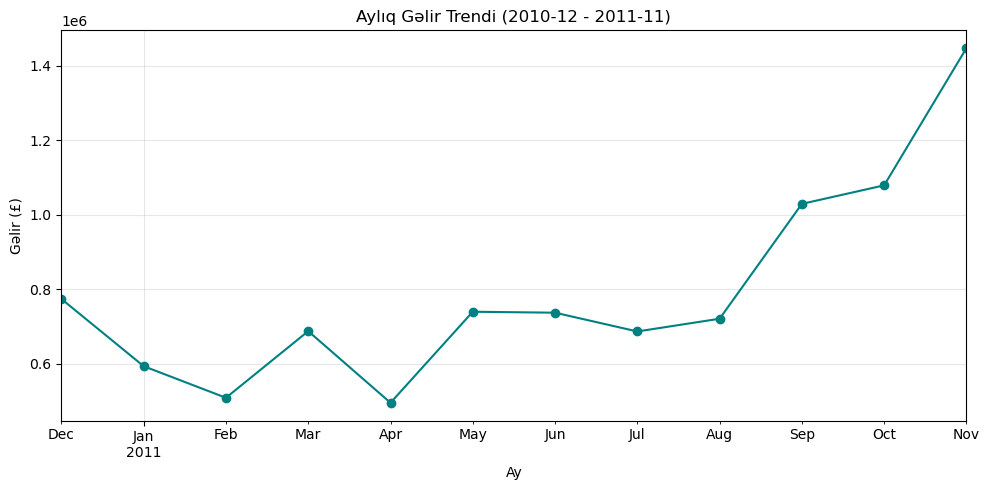

In [61]:
import matplotlib.pyplot as plt
monthly_final = df_products_final[df_products_final['InvoiceDate'] < '2011-12-01'].groupby(
    df_products_final['InvoiceDate'].dt.to_period('M')
)['Revenue'].sum()

plt.figure(figsize = (10,5))
monthly_final.plot(kind = 'line', marker = 'o', color = 'teal')
plt.title('Aylıq Gəlir Trendi (2010-12 - 2011-11)')
plt.xlabel('Ay')
plt.ylabel('Gəlir (£)')
plt.grid(True,alpha = 0.3)
plt.tight_layout()
plt.savefig('monthly_trend.png',dpi = 150)
plt.show()


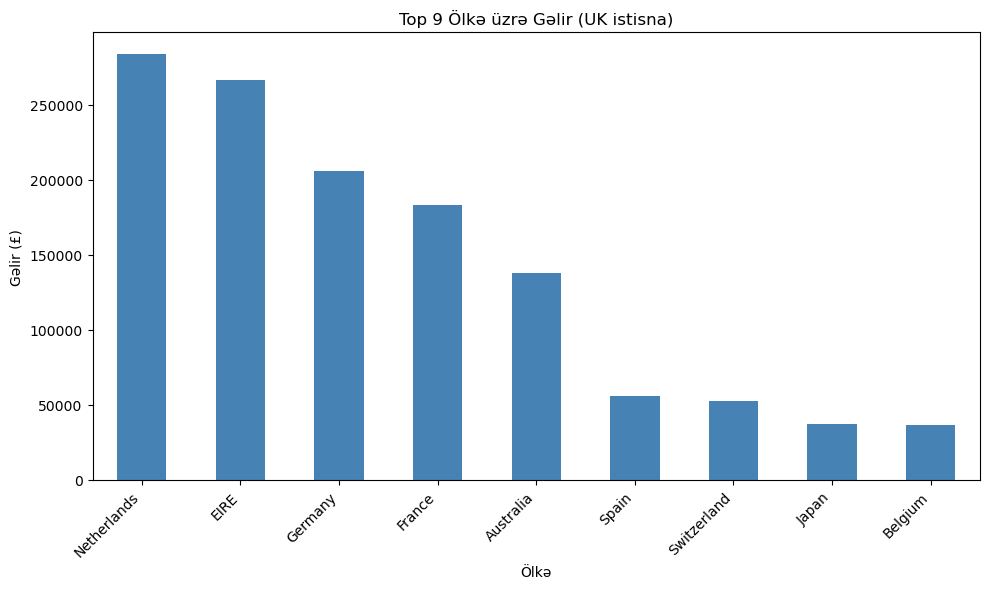

In [62]:
country_top9 = country_revenue_final.drop('United Kingdom').head(9)
plt.figure(figsize = (10,6))
country_top9.plot(kind = 'bar', color = 'steelblue')
plt.title('Top 9 Ölkə üzrə Gəlir (UK istisna)')
plt.xlabel('Ölkə')
plt.ylabel('Gəlir (£)')
plt.xticks(rotation = 45,ha = 'right')
plt.tight_layout()
plt.savefig('country_revenue.png',dpi = 150)
plt.show()

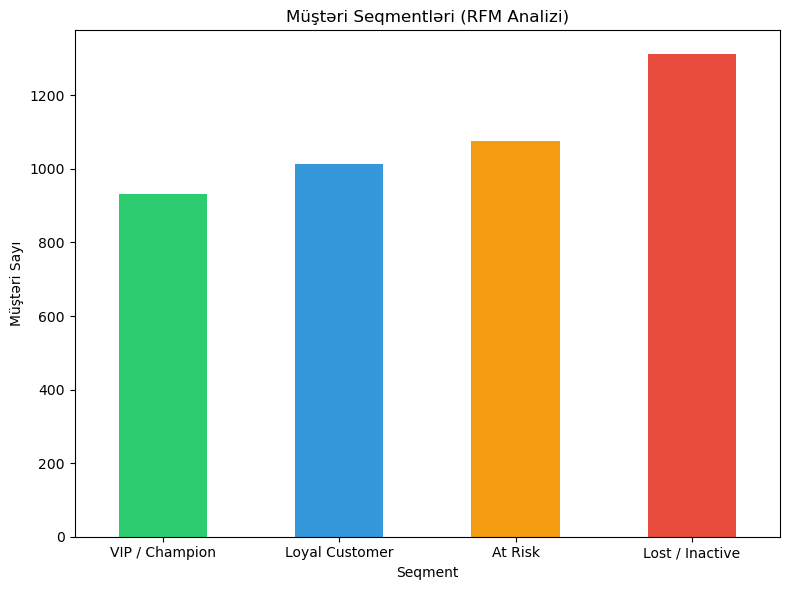

In [63]:
color_map = {
    'VIP / Champion': '#2ecc71',      # yaşıl
    'Loyal Customer': '#3498db',      # mavi
    'At Risk': '#f39c12',             # narıncı
    'Lost / Inactive': '#e74c3c'      # qırmızı
}

segment_order = ['VIP / Champion', 'Loyal Customer', 'At Risk', 'Lost / Inactive']
segment_counts_ordered = rfm_final['Segment'].value_counts().reindex(segment_order)
colors_ordered = [color_map[seg] for seg in segment_order]

plt.figure(figsize=(8,6))
segment_counts_ordered.plot(kind='bar', color=colors_ordered)
plt.title('Müştəri Seqmentləri (RFM Analizi)')
plt.xlabel('Seqment')
plt.ylabel('Müştəri Sayı')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('rfm_segments.png', dpi=150)
plt.show()


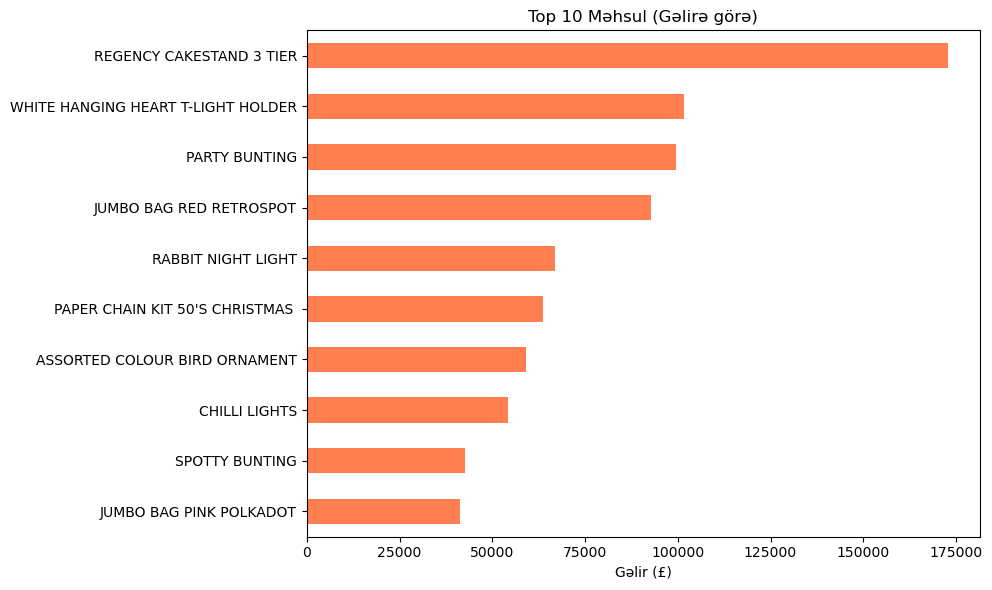

In [65]:
top10_final = df_products_final.groupby('Description')['Revenue'].sum().sort_values(ascending = False).head(10)
plt.figure(figsize = (10,6))
top10_final.sort_values().plot(kind = 'barh',color = 'coral')
plt.title('Top 10 Məhsul (Gəlirə görə)')
plt.xlabel('Gəlir (£)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('top10_products.png', dpi=150)
plt.show()